In [ ]:
pip install pandas

In [ ]:
import pandas as pd

# Step 1: Load the CSV file into a DataFrame
input_file = "full data (1).csv"  # Replace with your actual file name
output_file = "merged_full_data.csv"  # Name of the output file

# Read the CSV file
df = pd.read_csv(input_file, engine='python')

# Step 2: Merge the 'title' and 'text' columns into one column
# Use a space (' ') to separate the title and text
df['merged_text'] = df['title'].fillna('') + " " + df['text'].fillna('')

# Step 3: Drop the original 'title' and 'text' columns (optional)
# If you want to keep them, skip this step
df = df.drop(columns=['title', 'text'])

# Step 4: Save the updated DataFrame to a new CSV file
df.to_csv(output_file, index=False)

print(f"Merged data saved to {output_file}")

Merged data saved to merged_full_data.csv


In [ ]:
import pandas as pd

input_file = "full data (1).csv"
output_file = "merged_full_data.csv"

# 🔧 Read CSV with robust error handling
df = pd.read_csv(
    input_file,
    encoding='utf-8',           # Handles emojis, special chars, and Arabic/Latin text
    on_bad_lines='skip',        # Skips corrupted/malformed rows instead of crashing
    low_memory=False,           # Prevents dtype inference warnings on large files
    engine='c'                  # C-engine is faster & more forgiving with messy CSVs
)

# 📝 Merge 'title' and 'text' safely
df['merged_text'] = df['title'].fillna('') + " " + df['text'].fillna('')

# 🗑️ Drop original columns (errors='ignore' prevents crashes if columns are already missing)
df = df.drop(columns=['title', 'text'], errors='ignore')

# 💾 Save to new CSV
df.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ Merged data saved to {output_file}")
print(f"📊 Total rows processed: {len(df)}")

✅ Merged data saved to merged_full_data.csv
📊 Total rows processed: 110834


In [ ]:
# Quick fix for unclosed quotes before reading
with open(input_file, 'r', encoding='utf-8', errors='replace') as f:
    cleaned_lines = [line.rstrip() for line in f]
with open(input_file, 'w', encoding='utf-8') as f:
    f.writelines(cleaned_lines)

In [ ]:
  import nltk
  nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
################################# جديييييييييييييييييييييييييييييد

In [ ]:
import pandas as pd
import re
import gensim
from gensim import corpora, models

# 1. تحميل الملف الناتج من كود الدمج السابق
input_file = "merged_full_data.csv"
df = pd.read_csv(input_file)
print(f"✅ تم تحميل {len(df)} منشور من {input_file}")

# 2. دالة تنظيف النص (مطابقة تماماً للمنهجية في القسم 3.2)
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['cleaned_text'] = df['merged_text'].apply(clean_text)
df = df[df['cleaned_text'].str.strip() != '']  # إزالة الأسطر التي أصبحت فارغة بعد التنظيف
print(f"✅ {len(df)} منشور صالح بعد التنظيف.")

# 3. بناء القاموس وتدريب نموذج LDA (مثبت على 10 مواضيع)
texts = [doc.split() for doc in df['cleaned_text']]
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.5)  # مطابق للقسم 3.4 في ورقتك
corpus = [dictionary.doc2bow(text) for text in texts]

NUM_TOPICS = 10
print(f"🔄 جاري تدريب نموذج LDA بـ {NUM_TOPICS} مواضيع...")
lda_model = models.LdaModel(
    corpus=corpus, id2word=dictionary, num_topics=NUM_TOPICS,
    passes=20, random_state=42
)

# 4. تعيين الموضوع المهيمن لكل منشور
def get_dominant_topic(bow):
    dist = lda_model.get_document_topics(bow, minimum_probability=0)
    return max(dist, key=lambda x: x[1])[0]

df['dominant_topic'] = df['cleaned_text'].apply(
    lambda x: get_dominant_topic(dictionary.doc2bow(x.split()))
)

# 5. استخراج اقتباسين واقعيين لكل موضوع من النص الأصلي (merged_text)
# نستخدم merged_text بدلاً من cleaned_text للحفاظ على السياق البشري الأصلي
quotes_table = []
for topic_id in range(NUM_TOPICS):
    subset = df[df['dominant_topic'] == topic_id]
    if len(subset) >= 2:
        samples = subset.sample(2, random_state=42)
        quotes = [str(t)[:250] + "..." if len(str(t)) > 150 else t for t in samples['merged_text']]
    else:
        quotes = [str(subset.iloc[0]['merged_text'])[:150] + "..."] if len(subset) == 1 else ["Insufficient data"]
    quotes_table.append(quotes)

# 6. طباعة النتائج بصيغة جاهزة للنسخ مباشرة إلى جدول الورقة
print("\n" + "="*70)
print("📊 جدول الاقتباسات التمثيلية (جاهز للنسخ إلى Table 5)")
print("="*70)
for i, quotes in enumerate(quotes_table):
    print(f"\nTopic {i}:")
    for q in quotes:
        print(f'  "{q}"')

/tmp/ipykernel_5549/1249545318.py:8: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


✅ تم تحميل 110834 منشور من merged_full_data.csv
✅ 110780 منشور صالح بعد التنظيف.
🔄 جاري تدريب نموذج LDA بـ 10 مواضيع...

📊 جدول الاقتباسات التمثيلية (جاهز للنسخ إلى Table 5)

Topic 0:
  "ChatGPT "
  "Large Language model&GenAi Hi, where can i study how genAI works, in particular with focus at language processing, LLM, GPT model, and chatbot as ChatGpt? I should to find book or other resources to study these topics.
Thanks a lot!..."

Topic 1:
  "ChatGPTâ€™s problem Solving Capabilities on different context length Hey everyone,

We recently worked on a paper titledآ **"Assessing ChatGPTâ€™s Code Generation Capabilities with Short vs Long Context Programming Problems"**, where we systematicall..."
  "[P] I tried to teach Mistral 7B a new language (Sundanese) and it worked! (sort of) [Nero10578/Mistral-7B-Sunda-v1.0 آ· Hugging Face](https://huggingface.co/Nero10578/Mistral-7B-Sunda-v1.0)
I'll start by saying I am not a machine learning expert and ..."

Topic 2:
  "[HOLIDAY PROMO] Perplexi

In [ ]:
# استخراج 5 اقتباسات إضافية لكل موضوع للمراجعة اليدوية
for topic_id in range(10):
    subset = df[df['dominant_topic'] == topic_id]
    samples = subset.dropna(subset=['merged_text']).sample(5, random_state=42)
    print(f"\n=== Topic {topic_id} - Options ===")
    for i, txt in enumerate(samples['merged_text'], 1):
        preview = str(txt)[:200].replace('\n', ' ').strip()
        print(f"{i}. \"{preview}...\"")


=== Topic 0 - Options ===
1. "ChatGPT..."
2. "Large Language model&GenAi Hi, where can i study how genAI works, in particular with focus at language processing, LLM, GPT model, and chatbot as ChatGpt? I should to find book or other resources to s..."
3. "Get prompt inspiration with OnPrompt: Turn Any Image into a Prompt for DALL-E or Midjourney Hey everyone, I'm still relatively new to AI image generation. While the learning experience has been thrill..."
4. "[D] what is the advantage and disadvantage of using custom neural network for a secondary meta learner of a stacked ensemble, than using a traditional classifier? Is this even possible? Every journals..."
5. "Prompt Help: Daily news article updates Hello, Iâ€™m trying to get chat gpt 4 to give me daily news updates but every day they give me articles from 2 years ago even though I specify the date and set..."

=== Topic 1 - Options ===
1. "ChatGPTâ€™s problem Solving Capabilities on different context length Hey everyone,  We rece

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources (run this only once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load your dataset
input_file = "merged_full_data.csv"  # Replace with your actual file name
df = pd.read_csv(input_file)

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define a preprocessing function
def preprocess_text(text):
    # 1. Lowercase the text
    text = str(text).lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenize the text
    tokens = word_tokenize(text)

    # 5. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 6. Lemmatize the tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 7. Join tokens back into a single string
    cleaned_text = ' '.join(tokens)

    return cleaned_text

# Apply preprocessing to the 'merged_text' column
df['cleaned_text'] = df['merged_text'].apply(preprocess_text)

# Save the preprocessed data to a new CSV file
output_file = "preprocessed_data.csv"
df.to_csv(output_file, index=False)

print(f"Preprocessed data saved to {output_file}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/tmp/ipykernel_3640/1047813168.py:15: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


Preprocessed data saved to preprocessed_data.csv


In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources (run this only once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load your dataset
input_file = "preprocessed_data.csv"  # Replace with your actual file name
df = pd.read_csv(input_file)

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define a list of domain-specific noise terms
domain_specific_noise = [
    "chatgpt", "ai", "gpt", "llm", "model", "use", "like", "im", "ive",
    "response", "prompt", "data", "language", "tool", "openai", "google",
    "human", "user", "question", "paper", "llama", "openais", "deepseek",
    "perplexity", "chrome", "app", "apps", "code"
]

# Define a list of generic terms
generic_terms = [
    "new", "using", "know", "think", "help", "really", "make", "want",
    "say", "used", "need", "time", "work", "also", "even", "still",
    "many", "much", "well", "way", "thing", "something", "anything"
]

# Combine stop words, domain-specific noise, and generic terms
combined_noise = set(stop_words).union(domain_specific_noise).union(generic_terms)

# Define a preprocessing function
def preprocess_text(text):
    # 1. Lowercase the text
    text = str(text).lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenize the text
    tokens = word_tokenize(text)

    # 5. Remove stopwords, domain-specific noise, and generic terms
    tokens = [word for word in tokens if word not in combined_noise]

    # 6. Lemmatize the tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 7. Join tokens back into a single string
    cleaned_text = ' '.join(tokens)

    return cleaned_text

# Apply preprocessing to the 'merged_text' column
df['cleaned_text'] = df['merged_text'].apply(preprocess_text)

# Save the preprocessed data to a new CSV file
output_file = "preprocessed_data.csv"
df.to_csv(output_file, index=False)

print(f"Preprocessed data saved to {output_file}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/tmp/ipykernel_3640/549639496.py:15: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


Preprocessed data saved to preprocessed_data.csv


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 11.6 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']  # Compound score ranges from -1 (negative) to +1 (positive)

# Apply sentiment analysis
df['sentiment_score'] = df['cleaned_text'].apply(get_sentiment)

# Categorize sentiment into positive, negative, or neutral
def categorize_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['sentiment_score'].apply(categorize_sentiment)

# Save the results
df.to_csv("sentiment_analysis_results.csv", index=False)

print("Sentiment analysis completed.")

KeyError: 'cleaned_text'

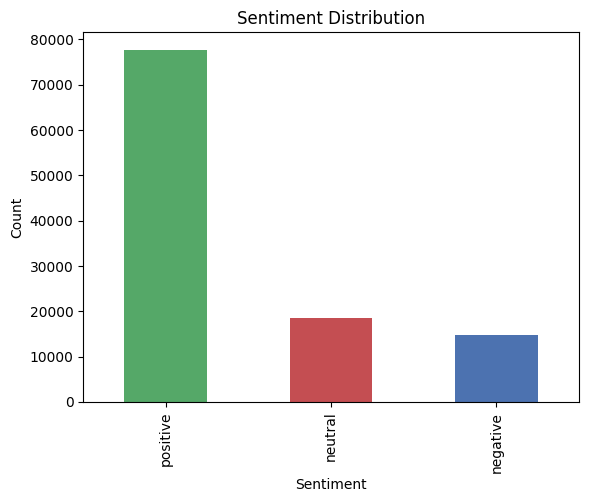

In [ ]:

import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', color=['#55A868', '#C44E52', '#4C72B0'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

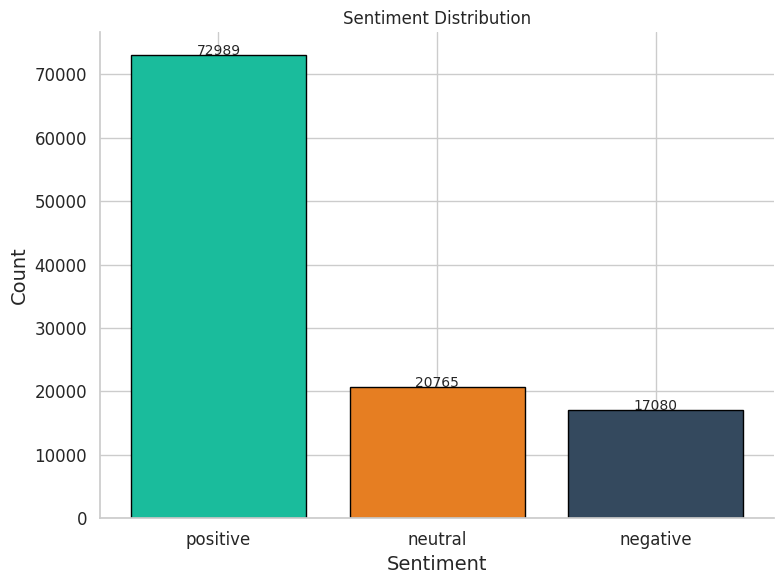

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns  # For better styling

# Set a professional style using Seaborn
sns.set(style="whitegrid")  # Adds a clean grid background
plt.figure(figsize=(8, 6))  # Adjust figure size for better proportions

# Count sentiment occurrences
sentiment_counts = df['sentiment'].value_counts()

# Define colors for each sentiment category
#colors = ['#55A868', '#A85568', '#B8B8B8']# Green, Red, Blue (customized)   '#55A868', '#C44E52', '#4C72B0'
colors = ['#1ABC9C', '#E67E22', '#34495E']
# Plot the bar chart
bar_plot = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')

# Add value labels on top of each bar
for bar in bar_plot:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}', ha='center', fontsize=10)

# Add title and axis labels
plt.title('Sentiment Distribution', fontsize=12)
plt.xlabel('Sentiment', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Customize ticks for better readability
plt.xticks(fontsize=12, rotation=0)  # No rotation needed for short labels
plt.yticks(fontsize=12)

# Remove spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add padding to prevent clipping of labels
plt.tight_layout()

# Save the figure as a high-resolution image
plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches='tight')  # Save as PNG


# Show the plot (optional, if you want to preview it)
plt.show()

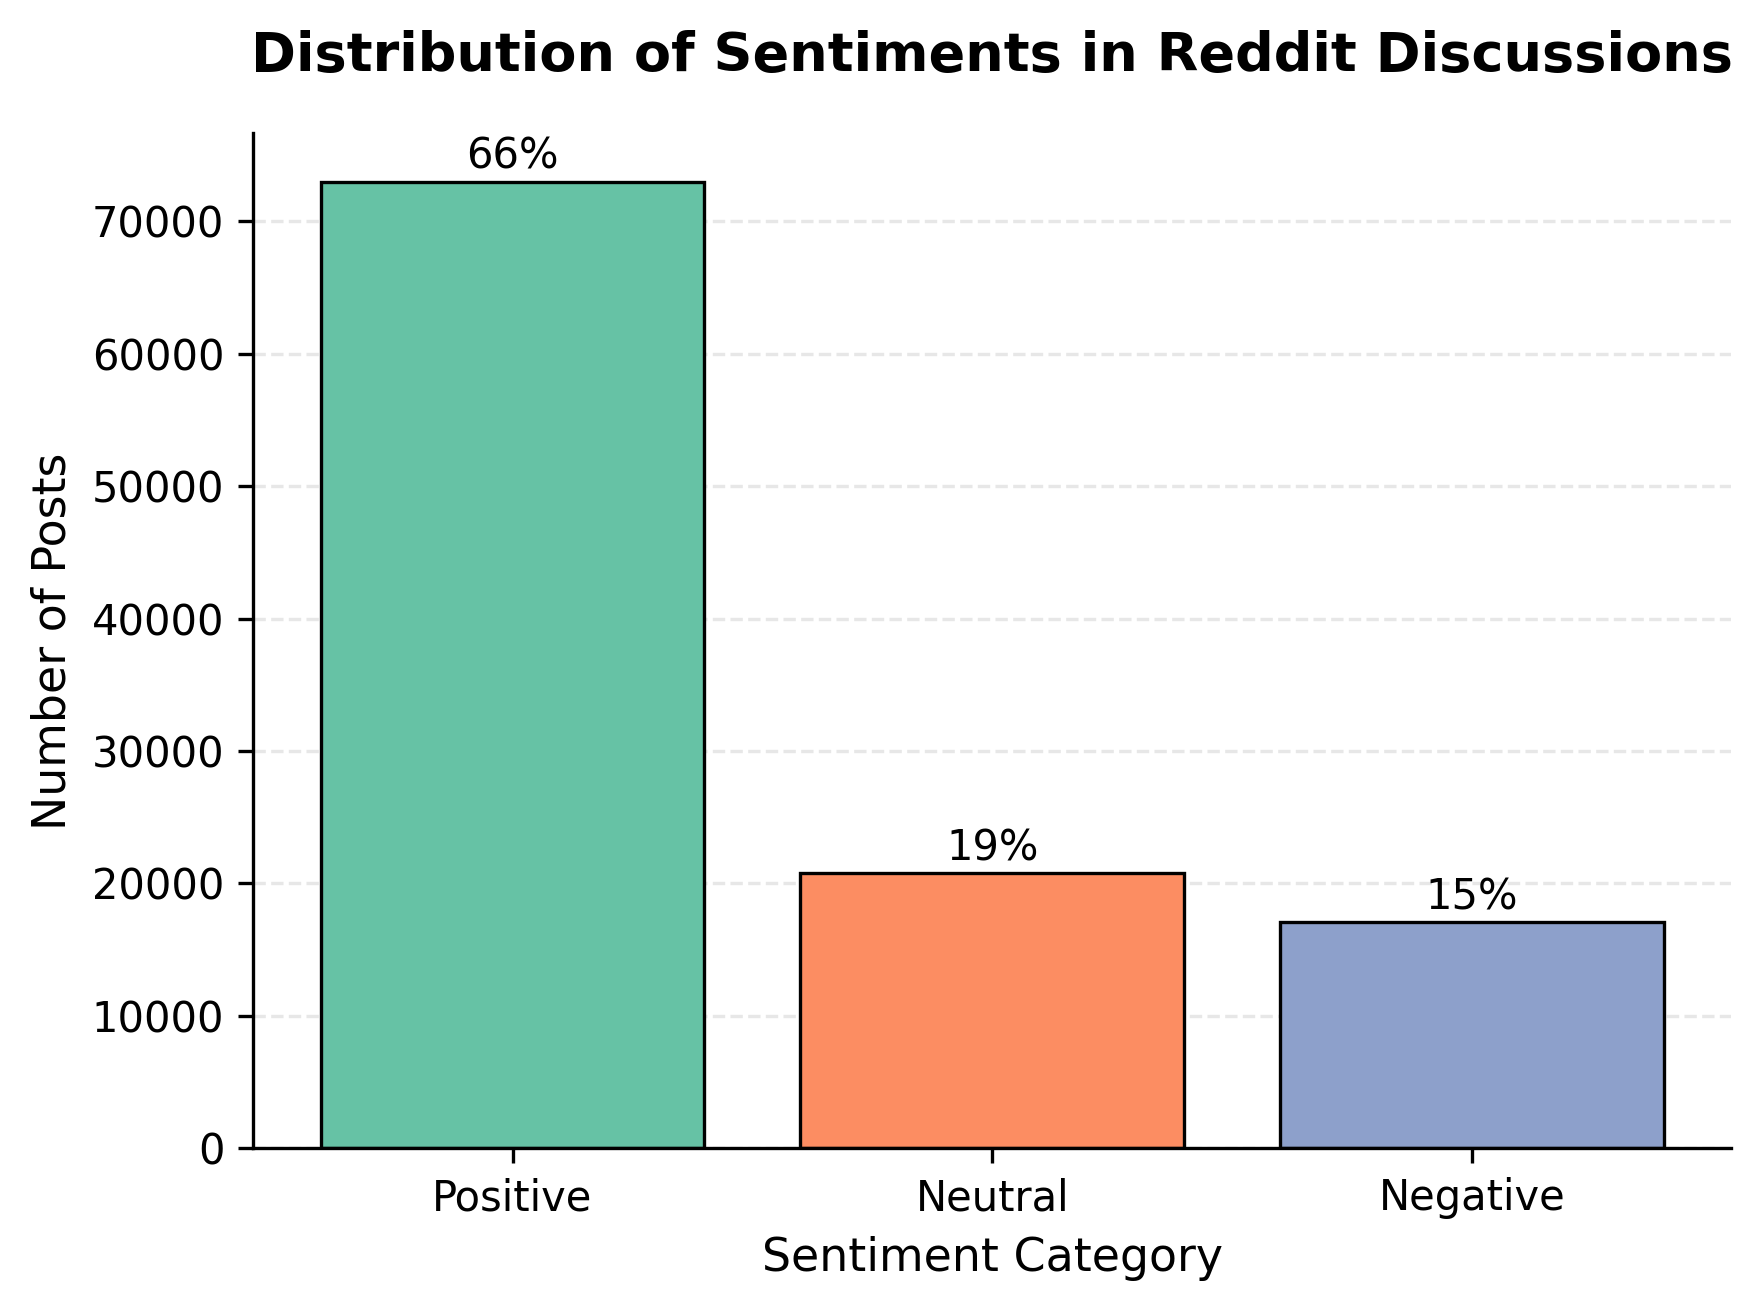

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# بيانات المشاعر من ورقتك
sentiment_counts = pd.Series({
    'Positive': 72989,   # 65%
    'Neutral': 20765,    # 19%
    'Negative': 17080    # 15%
})

# لوحة ألوان صديقة لعمى الألوان
colors = ['#66C2A5', '#FC8D62', '#8DA0CB']  # ColorBrewer Set2

# إعدادات النشر الاحترافي
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,  # دقة عالية للنشر
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf'  # أو 'png' حسب طلب المجلة
})

# إنشاء المخطط
fig, ax = plt.subplots(figsize=(6, 4.5))  # حجم مناسب لعمود واحد
bars = ax.bar(sentiment_counts.index, sentiment_counts.values,
              color=colors, edgecolor='black', linewidth=0.8)

# إضافة التسميات والأرقام
ax.set_xlabel('Sentiment Category', fontsize=11)
ax.set_ylabel('Number of Posts', fontsize=11)
ax.set_title('Distribution of Sentiments in Reddit Discussions',
             fontsize=13, weight='bold', pad=15)

# إضافة النسب المئوية فوق الأعمدة
for bar, count in zip(bars, sentiment_counts.values):
    pct = (count / sentiment_counts.sum()) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{pct:.0f}%', ha='center', va='bottom', fontsize=10)

# شبكة خفيفة للقراءة
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# إزالة الحدود العلوية واليمنى (أسلوب احترافي)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# حفظ الملف بجودة نشر
plt.tight_layout()
plt.savefig('figure2_sentiment_distribution.pdf', bbox_inches='tight')
plt.show()

In [ ]:
#Topic modeling
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the cleaned text
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# Apply LDA
lda = LatentDirichletAllocation(n_components=10, random_state=42)  # Extract 5 topics
topic_distribution = lda.fit_transform(X)

# Assign the dominant topic to each document
df['dominant_topic'] = topic_distribution.argmax(axis=1)

# Print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), 10)

Topic #0:
plan search pro year user gemini content information offer microsoft
Topic #1:
image people dont job chat llm plus better prompt question
Topic #2:
year answer software people project job feel student image day
Topic #3:
game study say create memory video survey tech save education
Topic #4:
step instruction specific custom llm model document question information text
Topic #5:
intelligence artificial podcast model chatbot safety technology company tech world
Topic #6:
apple copy learning update million deep image worker law list
Topic #7:
voice model token context text mixtral assistant output training opensource
Topic #8:
chat free conversation story chatbot prompt user best xb site
Topic #9:
robot python chat writing agent translate script good english create


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.0 MB/s eta 0:00:00


In [ ]:
import gensim
print("✅ Gensim version:", gensim.__version__)

ModuleNotFoundError: No module named 'gensim'

In [ ]:
import pandas as pd
import gensim
from gensim import corpora, models
from gensim.models import CoherenceModel
import warnings

# تجاهل التحذيرات غير الضرورية للحفاظ على نظافة المخرجات
warnings.filterwarnings('ignore')

# 1. تحميل البيانات المعالجة مسبقاً
df = pd.read_csv("preprocessed_data.csv")

# 2. تحويل النص المنظف إلى قائمة قوائم (Tokenized List) - مطلوب لـ Gensim
texts = [str(doc).split() for doc in df['cleaned_text']]

# إزالة المستندات الفارغة التي قد تنتج بعد التنقية
texts = [doc for doc in texts if len(doc) > 0]

print(f"✅ Loaded {len(texts)} valid documents for topic modeling.\n")

# 3. بناء القاموس والـ Corpus مع تطبيق الفلاتر المذكورة في الورقة
dictionary = corpora.Dictionary(texts)
# min_df=2 -> no_below=2, max_df=0.5 -> no_above=0.5
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in texts]

# 4. إعداد قائمة عدد المواضيع للمقارنة
topic_counts = [5, 10, 15]
comparison_results = []

print("🔄 Training LDA models and calculating Coherence Scores...\n" + "="*50)

for k in topic_counts:
    print(f"📊 Training LDA with {k} topics...")

    # تدريب النموذج
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=20,          # مطابق للورقة
        random_state=42,    # مطابق للورقة
        per_word_topics=True
    )

    # حساب درجة الاتساق (Coherence Score) بشكل مستقل
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'     # المقياس المعتمد في أبحاث الـ NLP
    )
    coherence_score = coherence_model.get_coherence()

    # استخراج أهم 10 كلمات لكل موضوع
    top_words = {f"Topic_{i}": [w for w, p in lda_model.show_topic(i, topn=10)] for i in range(k)}

    # حفظ النتائج
    comparison_results.append({
        "num_topics": k,
        "coherence_score": round(coherence_score, 4),
        "top_words_per_topic": top_words
    })

    print(f"✅ Coherence Score: {coherence_score:.4f}")
    print(f"🔤 Top words: {top_words}\n" + "-"*50)

# 5. عرض جدول المقارنة النهائي
results_df = pd.DataFrame(comparison_results)[["num_topics", "coherence_score"]]
print("\n📈 FINAL COMPARISON TABLE (Update Table 4 in your paper with these values):")
print(results_df.to_string(index=False))

# حفظ النتائج لمرجعك الشخصي
results_df.to_csv("lda_coherence_comparison.csv", index=False)

✅ Loaded 110834 valid documents for topic modeling.

🔄 Training LDA models and calculating Coherence Scores...
📊 Training LDA with 5 topics...
✅ Coherence Score: 0.4180
🔤 Top words: {'Topic_0': ['would', 'dont', 'people', 'chat', 'get', 'one', 'good', 'kupas', 'story', 'writing'], 'Topic_1': ['could', 'technology', 'company', 'future', 'would', 'tech', 'potential', 'system', 'people', 'year'], 'Topic_2': ['model', 'video', 'xb', 'project', 'search', 'application', 'survey', 'learning', 'chat', 'llm'], 'Topic_3': ['text', 'model', 'would', 'llm', 'input', 'example', 'training', 'xb', 'answer', 'could'], 'Topic_4': ['content', 'task', 'response', 'context', 'generate', 'llm', 'model', 'best', 'source', 'text']}
--------------------------------------------------
📊 Training LDA with 10 topics...
✅ Coherence Score: 0.3698
🔤 Top words: {'Topic_0': ['would', 'could', 'year', 'moon', 'j', 'may', 'message', 'one', 'however', 'wear'], 'Topic_1': ['would', 'system', 'people', 'future', 'technolog

In [ ]:
import pandas as pd

# Load your cleaned dataset (after initial preprocessing)
df = pd.read_csv("merged_full_data.csv")  # n = 110,834

print(f"Starting posts: {len(df):,}")

# Step 1: Engagement filter (score >= 5)
df_eng = df[df['score'] >= 5]
removed_eng = len(df) - len(df_eng)
print(f"1. After engagement filter (score >= 5): {len(df_eng):,} posts (removed {removed_eng:,})")

# Step 2: Length filter (>= 50 words after preprocessing)
# Assuming you have a 'cleaned_text' column with preprocessed content
df_len = df_eng[df_eng['cleaned_text'].str.split().str.len() >= 50]
removed_len = len(df_eng) - len(df_len)
print(f"2. After length filter (>= 50 words): {len(df_len):,} posts (removed {removed_len:,})")

# Step 3: Remove deleted/removed entries
df_clean = df_len[~df_len['body'].str.contains(r'\[deleted\]|\[removed\]', case=False, na=False)]
removed_deleted = len(df_len) - len(df_clean)
print(f"3a. After removing [deleted]/[removed]: {len(df_clean):,} posts (removed {removed_deleted:,})")

# Step 4: English-only filter (if you have a 'lang' column)
# If not, skip this or use a langdetect library
df_final = df_clean[df_clean['lang'] == 'en']  # Adjust column name as needed
removed_lang = len(df_clean) - len(df_final)
print(f"3b. After English-only filter: {len(df_final):,} posts (removed {removed_lang:,})")

print(f"\n✅ Final corpus for LDA: {len(df_final):,} posts")

Starting posts: 110,834


/tmp/ipykernel_8111/66708075.py:4: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_full_data.csv")  # n = 110,834


TypeError: '>=' not supported between instances of 'str' and 'int'

In [ ]:
import pandas as pd

# 1. تحميل البيانات
df = pd.read_csv("merged_full_data.csv")

# 2. إصلاح خطأ النوع: تحويل score إلى أرقام (القيم غير الصالحة تصبح NaN)
df['score'] = pd.to_numeric(df['score'], errors='coerce')

print(f"📦 Starting posts: {len(df):,}")

# 3. فلتر التفاعل (Engagement)
df_eng = df[df['score'] >= 5]
removed_eng = len(df) - len(df_eng)
print(f"1️⃣ Engagement filter (score >= 5): {len(df_eng):,} posts (removed {removed_eng:,})")

# 4. فلتر الطول (>= 50 كلمة)
# ⚠️ غيّر 'cleaned_text' إلى اسم العمود الفعلي الذي يحتوي على النص بعد التنظيف
text_col = 'cleaned_text'
df_len = df_eng[df_eng[text_col].str.split().str.len() >= 50]
removed_len = len(df_eng) - len(df_len)
print(f"2️⃣ Length filter (>= 50 words): {len(df_len):,} posts (removed {removed_len:,})")

# 5. فلتر النظافة واللغة
# افحص عمود النص الأصلي للبحث عن [deleted] أو [removed]
raw_text_col = 'text'  # غيّره إذا كان اسم العمود مختلفاً في بياناتك
mask_deleted = df_len[raw_text_col].astype(str).str.contains(r'\[deleted\]|\[removed\]', case=False, na=False)
df_clean = df_len[~mask_deleted]
removed_deleted = len(df_len) - df_clean.shape[0]
print(f"3️⃣a Remove [deleted]/[removed]: {len(df_clean):,} posts (removed {removed_deleted:,})")

# فلتر اللغة الإنجليزية (إذا كان العمود موجوداً)
if 'lang' in df_clean.columns:
    df_final = df_clean[df_clean['lang'] == 'en']
    removed_lang = len(df_clean) - len(df_final)
    print(f"3️b English-only filter: {len(df_final):,} posts (removed {removed_lang:,})")
else:
    df_final = df_clean
    print("ℹ️ No 'lang' column found. Assuming remaining posts are English.")
    print(f"3️⃣b Final count after cleanliness filter: {len(df_final):,} posts")

print(f"\n✅ FINAL CORPUS FOR LDA: {len(df_final):,} posts")

📦 Starting posts: 110,834
1️⃣ Engagement filter (score >= 5): 46,497 posts (removed 64,337)


/tmp/ipykernel_8111/3989403717.py:4: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_full_data.csv")


KeyError: 'cleaned_text'

In [ ]:
import pandas as pd

# 1. تحميل البيانات (low_memory=False لإصلاح تحذير الأنواع المختلطة)
df = pd.read_csv("merged_full_data.csv", low_memory=False)

# طباعة الأعمدة للتأكد من اسم عمود النص الصحيح
print(" Available columns:", df.columns.tolist())

# 2. إصلاح عمود النقاط (score) ليصبح أرقاماً
df['score'] = pd.to_numeric(df['score'], errors='coerce')

print(f"\n📦 Starting posts: {len(df):,}")

# 3. فلتر التفاعل (Engagement)
df_eng = df[df['score'] >= 5]
removed_eng = len(df) - len(df_eng)
print(f"1️⃣ Engagement filter (score >= 5): {len(df_eng):,} posts (removed {removed_eng:,})")

# 4. فلتر الطول (Length)
# ⚠️ استخدمت 'merged_text' بناءً على كودك السابق. إذا كان اسمه مختلفاً، غيّريه هنا:
text_col = 'merged_text'

# حساب عدد الكلمات (نتجاهل القيم الفارغة لتجنب الأخطاء)
df_len = df_eng.dropna(subset=[text_col]).copy()
df_len['word_count'] = df_len[text_col].str.split().str.len()
df_len = df_len[df_len['word_count'] >= 50]

removed_len = len(df_eng) - len(df_len)
print(f"2️⃣ Length filter (>= 50 words): {len(df_len):,} posts (removed {removed_len:,})")

# 5. فلتر النظافة (Cleanliness) - البحث عن [deleted] أو [removed]
mask_deleted = df_len[text_col].astype(str).str.contains(r'\[deleted\]|\[removed\]', case=False, na=False)
df_clean = df_len[~mask_deleted]
removed_deleted = len(df_len) - len(df_clean)
print(f"3️⃣a Remove [deleted]/[removed]: {len(df_clean):,} posts (removed {removed_deleted:,})")

# 6. فلتر اللغة (English)
if 'lang' in df_clean.columns:
    df_final = df_clean[df_clean['lang'] == 'en']
    removed_lang = len(df_clean) - len(df_final)
    print(f"3️⃣b English-only filter: {len(df_final):,} posts (removed {removed_lang:,})")
else:
    df_final = df_clean
    print("️ No 'lang' column found. Assuming final count is same as cleanliness count.")
    print(f"3️⃣b Final count: {len(df_final):,} posts")

print(f"\n✅ FINAL CORPUS FOR LDA: {len(df_final):,} posts")

 Available columns: ['id', 'score', 'num_comments', 'url', 'subreddit', 'created_utc', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'merged_text']

📦 Starting posts: 110,834
1️⃣ Engagement filter (score >= 5): 46,497 posts (removed 64,337)
2️⃣ Length filter (>= 50 words): 27,600 posts (removed 18,897)
3️⃣a Remove [deleted]/[removed]: 27,600 posts (removed 0)
️ No 'lang' column found. Assuming final count is same as cleanliness count.
3️⃣b Final count: 27,600 posts

✅ FINAL CORPUS FOR LDA: 27,600 posts
